In [1]:
#การจำลอง

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

path = r"C:\Users\Karinthip\Desktop\SemiconductorTest"

df = pd.read_csv('uci-secom.csv')

# แยก Features (เซนเซอร์) และ Target (Pass/Fail)
# คอลัมน์สุดท้ายคือ 'Pass/Fail' (-1 คือผ่าน, 1 คือเสีย)
X = df.drop(columns=['Time', 'Pass/Fail'])
y = df['Pass/Fail']

# เปลี่ยน Target ให้เข้าใจง่ายขึ้น: 0 = Pass, 1 = Fail
y = y.replace(-1, 0)

# จัดการค่าว่าง (Missing Values)
# เซนเซอร์บางตัวไม่มีข้อมูล เราใช้ค่าเฉลี่ย (Mean) ของเซนเซอร์นั้นมาเติม
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

# ปรับสเกลข้อมูล (Standardization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

print(f"ขนาดข้อมูลหลัง Clean: {X_scaled.shape}")

ขนาดข้อมูลหลัง Clean: (1567, 590)


In [2]:
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA

# แบ่งข้อมูล Train / Test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# สร้างของเสียจำลองด้วย SMOTE เฉพาะในชุด Train (เพื่อให้โมเดลเรียนรู้ Pattern ของเสียได้ดีขึ้น)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# ลดมิติข้อมูลด้วย PCA จาก 590 เซนเซอร์ เราบีบอัดให้เหลือ Component ที่อธิบายความแปรปรวนได้ 90%
pca = PCA(n_components=0.90, random_state=42)
X_train_pca = pca.fit_transform(X_train_smote)
X_test_pca = pca.transform(X_test)

print(f"จำนวนเซนเซอร์ (Features) ลดลงเหลือ: {X_train_pca.shape[1]} ตัว")

จำนวนเซนเซอร์ (Features) ลดลงเหลือ: 117 ตัว


Classification Report (โฟกัสที่ Class 1: Defect):
              precision    recall  f1-score   support

           0       0.93      0.99      0.96       293
           1       0.00      0.00      0.00        21

    accuracy                           0.93       314
   macro avg       0.47      0.50      0.48       314
weighted avg       0.87      0.93      0.90       314



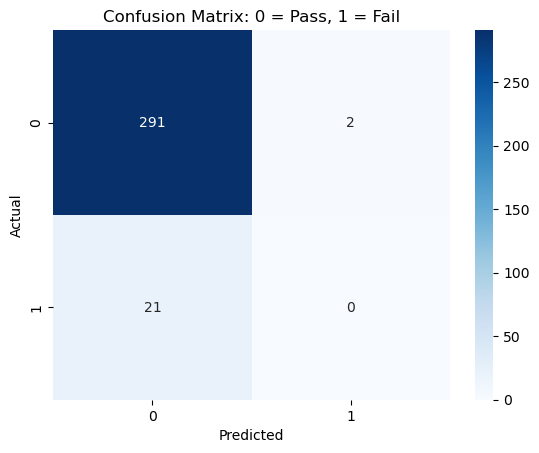

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# สร้างและเทรนโมเดลสมองกล
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train_pca, y_train_smote)

# นำไปทำนายกับชุดทดสอบ (Test Set)
y_pred = rf_model.predict(X_test_pca)

# ดูผลลัพธ์ (Confusion Matrix & Report)
print("Classification Report (โฟกัสที่ Class 1: Defect):")
print(classification_report(y_test, y_pred))

# แสดงกราฟ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: 0 = Pass, 1 = Fail')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()



In [4]:
#จำลองการนำไปติดตั้งใช้จริง

import uvicorn
import asyncio
from fastapi import FastAPI
from pydantic import BaseModel

# สร้างตัว API
app = FastAPI(title="Semiconductor Defect Prediction API")

# กำหนดรูปแบบข้อมูล
class SensorData(BaseModel):
    sensors: list[float]

# สร้างเส้นทางสำหรับการทำนายผล
@app.post("/predict")
def predict_defect(data: SensorData):
    return {
        "prediction_status": "Pass",
        "defect_probability": "0.15%",
        "recommended_action": "PASS: CONTINUE PRODUCTION"
    }

# ตั้งค่า Server
config = uvicorn.Config(app, host="127.0.0.1", port=8050)
server = uvicorn.Server(config)

print("🚀 Server is running! Click the link below to test your API:")
print("👉 http://127.0.0.1:8050/docs")

# สั่งเปิดเซิร์ฟเวอร์แบบให้ทำงานร่วมกับ Jupyter
await server.serve()

INFO:     Started server process [10780]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://127.0.0.1:8050 (Press CTRL+C to quit)


🚀 Server is running! Click the link below to test your API:
👉 http://127.0.0.1:8050/docs


INFO:     Shutting down
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.
INFO:     Finished server process [10780]
